## Notebook description: *Coconatfly_PhN_Cosine.ipynb*

This notebook performs a **clustering analysis of PhN (pharyngeal nerve) sensory axons** using the **FlyWire connectome** via the `coconatfly` R package (workflow adapted from *McKim et al. 2024*).

New coconatfly users should start with the coconatfly tutorial https://github.com/natverse/coconatfly/

### What it does (high-level)
1. **Loads a curated neuron list / annotations** from project CSV files in `PATH_input`.
2. **Defines the target PhN population** (FlyWire root IDs) and retrieves **FlyWire metadata** for those neurons.
3. **Computes output connectivity partners** (postsynaptic targets) for each neuron using `cf_partners(..., partners="outputs")`, applying a **synapse threshold** (e.g., ≥5) to focus on stronger connections.
4. Builds an output-connectivity representation and computes **pairwise cosine similarity** of output profiles.
5. Uses **hierarchical clustering** (Ward.D2) to group neurons by similarity of their downstream connectivity.
6. Produces a cosine-based clustering plot (dendrogram/heatmap view depending on settings), saves a **PDF** figure, and also plots inline.

### Key inputs
- `PhN_v1.0*.csv`: curated/annotated list of PhN neurons (contains `id` / root IDs plus annotations).
- A manually provided list of FlyWire **root IDs** (`ids_string`) used to query metadata/connectivity (here: “without putative DCSOs”).

### Key intermediate objects (as named in this notebook)
- `PhN`: curated annotation table loaded from CSV (first column renamed to `id`).
- `pharyngeal`: metadata table for the selected neurons (joined with `PhN` annotations).
- `pharyngeal_partners`: partner table from `cf_partners(..., partners="outputs")`.
- `pharyngeal$key`: connectivity-derived key used by `cf_cosine_plot(...)` for cosine similarity and clustering.

### Key outputs
- A clustering figure saved to PDF (see the plotting cell; filename includes `v`).
- Inline clustering plot for quick inspection.

### Notes / assumptions
- Connectivity is analyzed on **output synapses** (presynaptic neuron → downstream targets).
- Thresholds (partner threshold, cosine threshold, and optional filtering by total output synapses) affect which neurons/partners contribute to similarity and clustering.
- In FlyWire FAFB v783, aPhN = Accessory pharyngeal/aPharyngeal Nerve; PhN = Pharyngeal Nerve. In this analysis, the PhN consists of the stomodeal nerve (StN) and the Dorsal Cibarial Sensory Organ (DCSO), and pharyngeal nerve motor neurons (which are not included); the aPhN consists of axons of the Ventral Cibarial Sensory Organ (VCSO) and the Labral Sensory Organ (LSO). We consider the aPhN and PhN collectively as the PanPharyngeal sensory axons.

In [ ]:
# Quick notebook summary (prints what exists in the current kernel for THIS notebook)
summary_info <- list(
  paths = list(input = PATH_input, output = PATH_output),
  n_input_files = if (exists("input_files")) length(input_files) else NA_integer_,
  objects_present = c(
    PhN = exists("PhN"),
    pharyngeal = exists("pharyngeal"),
    pharyngeal_partners = exists("pharyngeal_partners")
  ),
  counts = list(
    PhN_rows = if (exists("PhN")) nrow(PhN) else NA_integer_,
    pharyngeal_rows = if (exists("pharyngeal")) nrow(pharyngeal) else NA_integer_,
    pharyngeal_partners_rows = if (exists("pharyngeal_partners")) nrow(pharyngeal_partners) else NA_integer_
  ),
  outputs = list(
    pdf_expected = if (exists("v")) paste0("../output/figures/fig_2/", v, ".pdf") else NA_character_
  )
)

print(summary_info)

## Output files produced by this notebook

If the output directory is writable, running the plotting cell will write:

- `../output/figures/fig_2{v}.pdf`

This file contains the PhN cosine-similarity clustering plot based on **output connectivity**.


In [1]:
#----Figure_2A-------------------------------------------------------------------
#-------------------------------------------------------------------------------
# This is the code for PhN clustering analysis, adapted from McKim et al. 2024
#-------------------------------------------------------------------------------

#-load packages-----------------------------------------------------------------
library(tidyverse)
library(coconatfly)

###general variables:-----------------------------------------------------------
set.seed(42)
options(scipen = 999)

PATH_input = "../input/input_coconatfly/"
PATH_output = "../output/figures/fig_2/"
version <- "1.0"  # Specify version manually

The following objects are masked from ‘package:base’:

    intersect, setdiff, union




In [2]:
input_files = list.files(path = PATH_input, full.names = FALSE, recursive = FALSE)

In [3]:
input_files_tmp = list.files(path = paste0(PATH_input,"tmp/"),
full.names = FALSE, recursive = FALSE)
input_files = c(input_files,input_files_tmp)
v = read_delim(paste0(PATH_input,"PhN_v1.0.csv"),
col_types  =  cols(version  =  col_character()),delim  =  ";")

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


In [4]:
v = v$version[1]

# set variables:----------------------------------------------------------------
PhN = read_delim(paste0(PATH_input,"PhN_v1.0",v,".csv"),
col_types = cols(root_id = col_character()),delim = ",")

Warning message:
“Unknown or uninitialised column: `version`.”


In [5]:
#-------------------------------------------------------------------------------
#clustering of all endocrine cells
colnames(PhN)[1] <- 'id'
# paste0(PhNid, collapse = ",")

#obtain meta data for all pharyngeal cells

In [6]:
#without putative DCSOs
ids_string <- paste(c(
    "720575940611959011", "720575940613004402", "720575940637896245", "720575940622198772",
    "720575940619652033", "720575940621207517", "720575940624905572", "720575940620910716",
    "720575940638357813", "720575940605161388", "720575940607166731", "720575940633579360",
    "720575940627274578", "720575940624910373", "720575940659479937", "720575940611388595",
    "720575940625471896", "720575940620528990", "720575940610897906", "720575940624724458",
    "720575940653233569", "720575940613347474", "720575940634755041", "720575940627107271",
    "720575940604355872", "720575940621106465", "720575940625941022", "720575940630574659",
    "720575940632040749", "720575940648377209", "720575940639972816", "720575940614641202",
    "720575940631205580", "720575940607152476", "720575940612256938", "720575940627989609",
    "720575940630434616", "720575940631572141", "720575940635501560", "720575940631070239",
    "720575940631462969", "720575940650760825", "720575940644676900", "720575940645493283",
    "720575940633194029", "720575940625871181", "720575940631963821", "720575940631049064",
    "720575940633895469", "720575940633129683", "720575940634085786", "720575940630654539",
    "720575940646039092", "720575940645524003", "720575940623056422", "720575940639786830",
    "720575940620983637", "720575940632743649", "720575940626311049", "720575940626396803",
    "720575940617034713", "720575940624502269", "720575940604782624", "720575940606163842",
    "720575940629887695", "720575940626767152", "720575940641265549", "720575940622144648",
    "720575940638086256", "720575940645108936", "720575940633129171", "720575940622575754",
    "720575940619316603", "720575940605682790", "720575940606239666", "720575940630806267",
    "720575940623951591", "720575940633759840", "720575940625785731"

),
    collapse = " ")

In [7]:
# Now, retrieve metadata for all root IDs using the concatenated string
pharyngeal<- cf_meta(cf_ids(ids_string, datasets = "flywire"))

Loading required namespace: git2r



In [8]:
pharyngeal= left_join(pharyngeal,PhN,by = "id")
pharyngeal$side_name_id = paste(
pharyngeal$side,
pharyngeal$name,pharyngeal$id,sep="")

In [9]:
library(bit64)

pharyngeal_partners <- pharyngeal%>%
cf_partners(
threshold = 5,        # Minimum synapse count
partners = "outputs"  # Focus on output synapses
)

# 4. Aggregate synapse counts per neuron
output_counts <- pharyngeal_partners %>%
group_by(pre_id) %>%
summarise(output_count = sum(weight))

# 5. Convert pre_id to character for compatibility
output_counts <- output_counts %>%
mutate(pre_id = as.character(pre_id))

# 6. Join counts back to metadata
pharyngeal<- pharyngeal%>%
left_join(output_counts, by = c("id" = "pre_id")) %>%
filter(output_count >= 4)

The following objects are masked from ‘package:base’:

    :, %in%, colSums, is.double, match, order, rank, rowSums




### Fig_2A


### Note
The .SVG file was edited in Adobe Illustrator for presentation purposes, see figure 2A.


In [10]:
# Generate the plot with corrected labels (use 'id' instead of 'side_name_id')
#dir.create(PATH_output, recursive = TRUE, showWarnings = FALSE)
svg(paste0(PATH_output, "PhN_clustermap_wardd2.svg"), width = 15, height = 10)



options(repr.plot.res = 300)
par(mar = c(15, 20, 4, 2) + 0.1, oma = c(5, 5, 5, 5))  # Adjust margins to make space for labels
pharyngeal%>%
with(cf_cosine_plot(
key,
threshold = 1,
labRow = id,  # Use raw root IDs for labels
interactive = FALSE,
partners = "outputs",
method = "ward.D2",
cexRow = 0.2,  # Reduce font size for row labels
cexCol = 0.2   # Reduce font size for column labels
))
dev.off()

agg_record_16962874 
                  2

In [11]:
# Generate the plot with corrected labels (use 'id' instead of 'side_name_id')
#dir.create(PATH_output, recursive = TRUE, showWarnings = FALSE)

pdf(
  file.path(PATH_output, paste0("PhN_clustermap_wardd2", v, ".pdf")),
  width = 15,
  height = 10
)
options(repr.plot.res = 300)
par(mar = c(15, 20, 4, 2) + 0.1, oma = c(5, 5, 5, 5))  # Adjust margins to make space for labels
pharyngeal%>%
with(cf_cosine_plot(
key,
threshold = 1,
labRow = id,  # Use raw root IDs for labels
interactive = FALSE,
partners = "outputs",
method = "ward.D2",
cexRow = 0.2,  # Reduce font size for row labels
cexCol = 0.2   # Reduce font size for column labels
))
dev.off()

agg_record_1746377886 
                    2

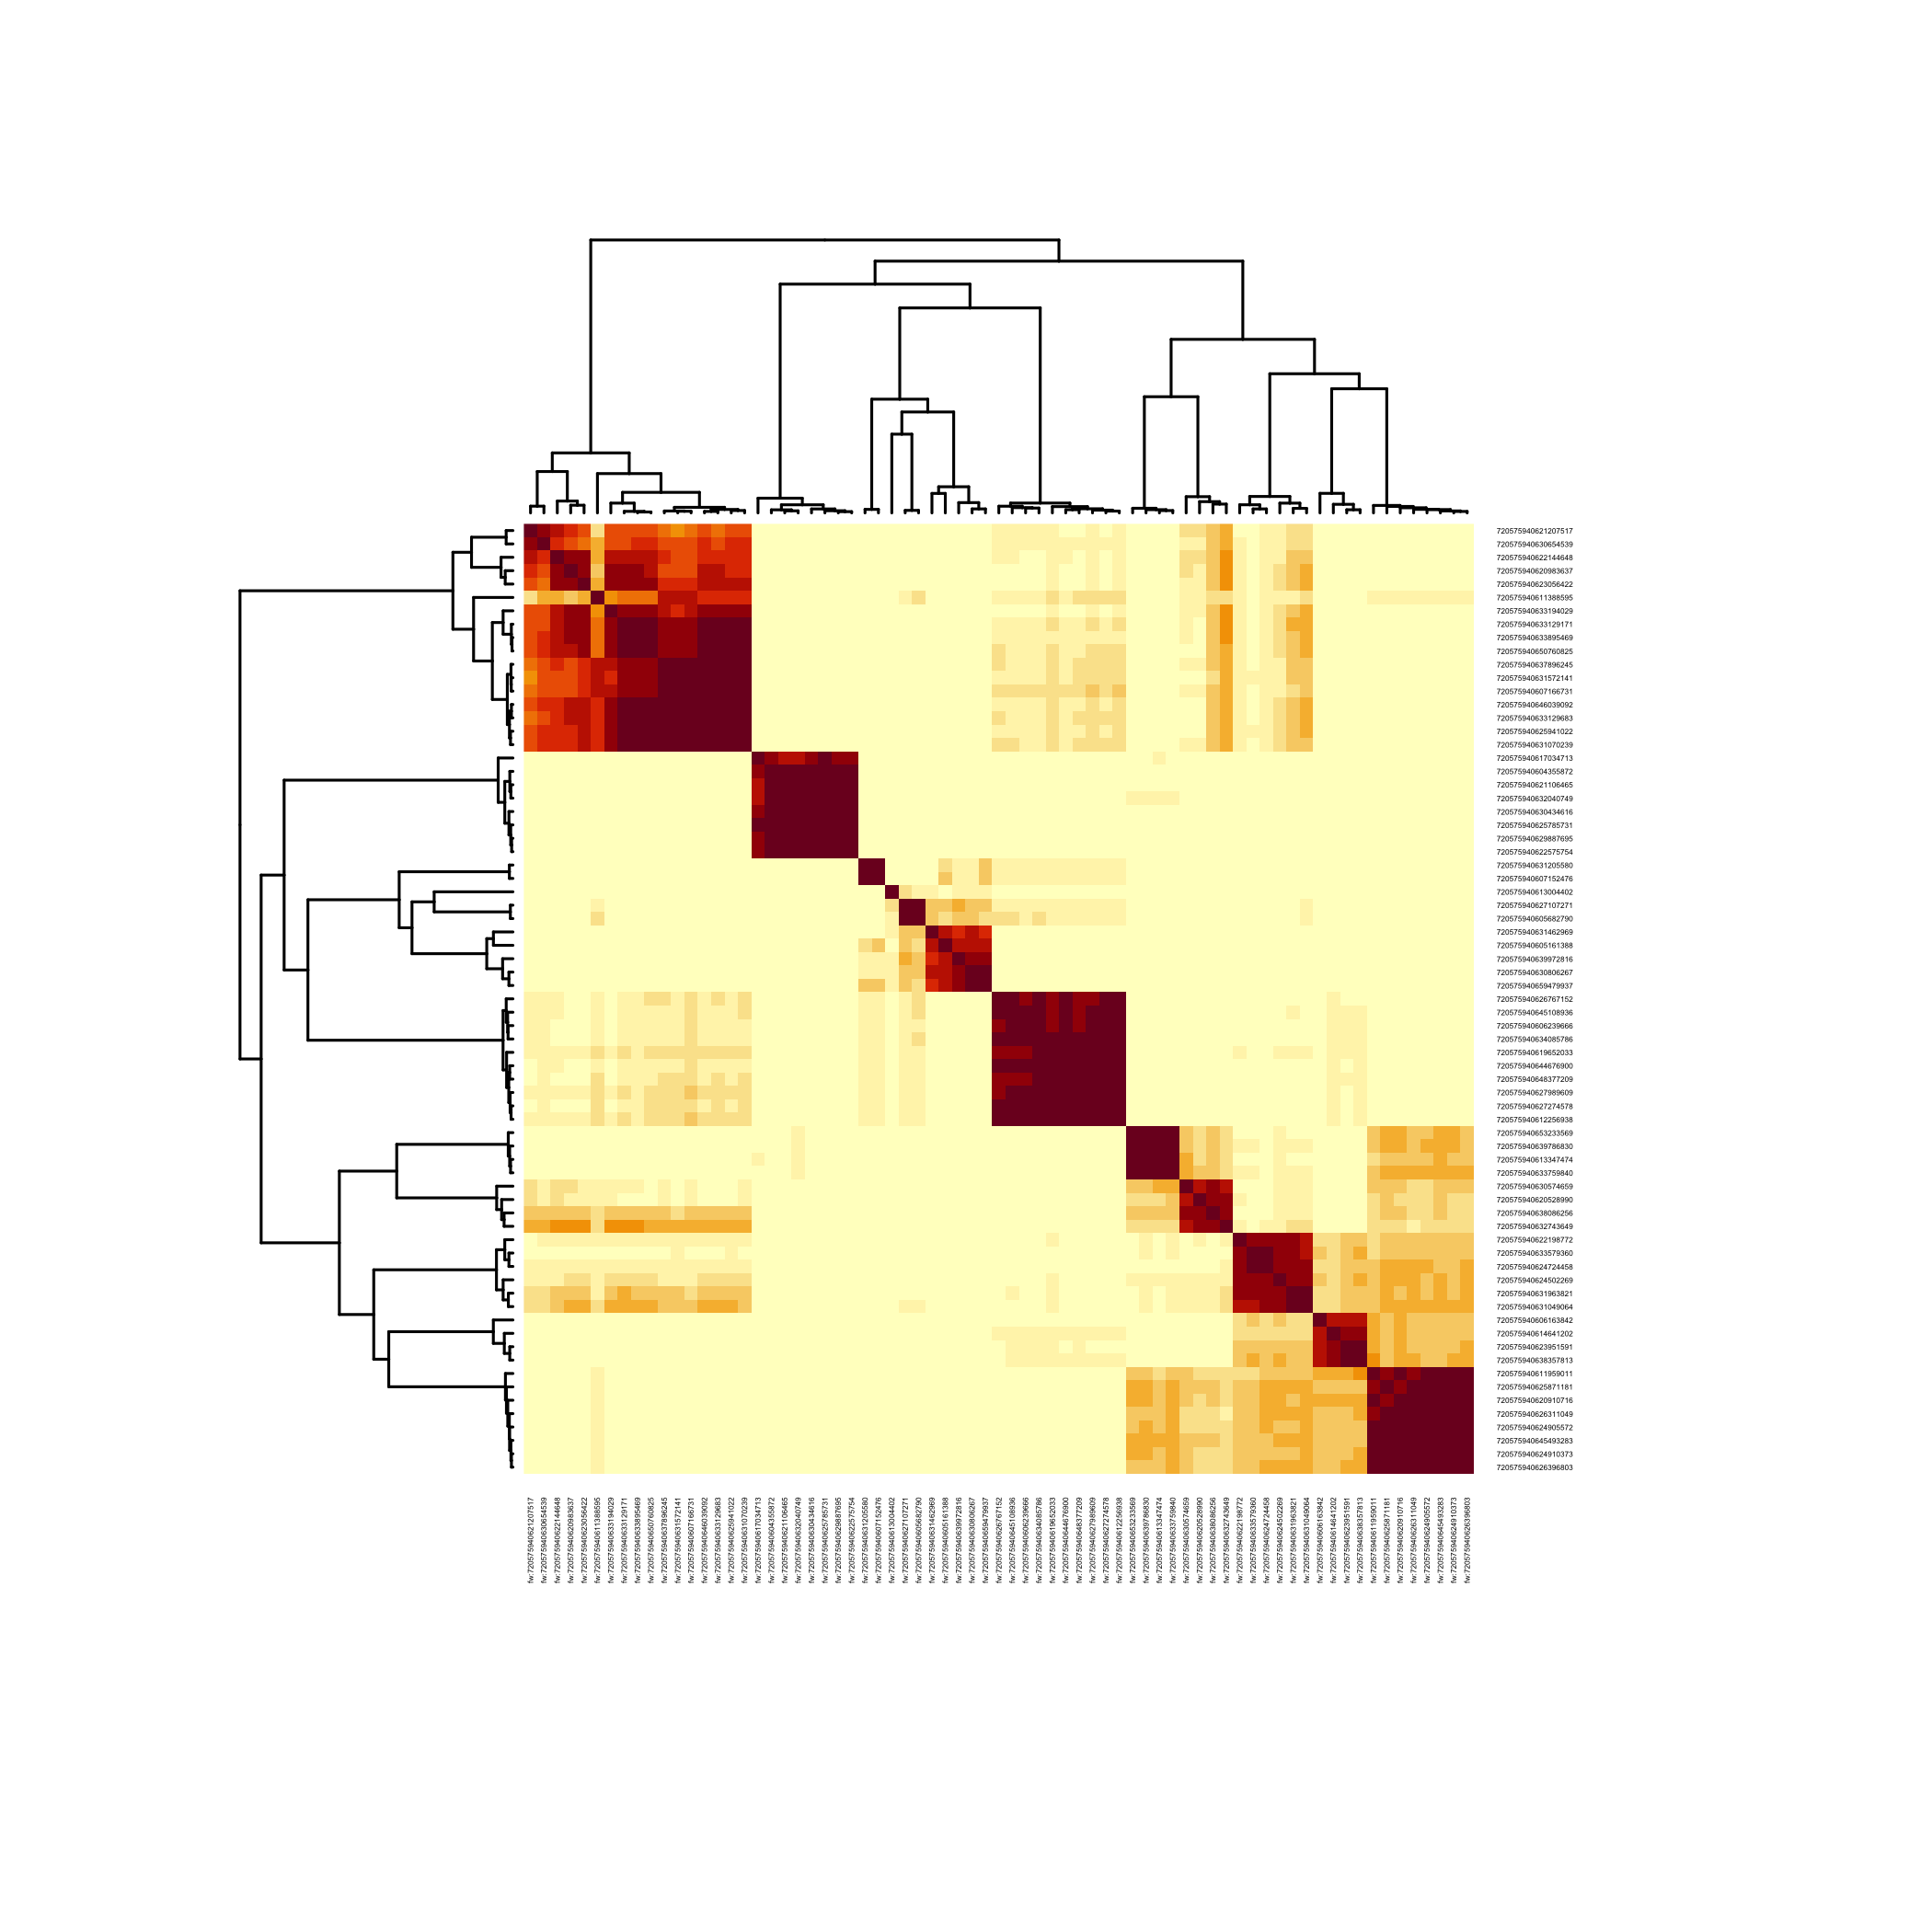

In [12]:
# Generate the plot with corrected labels (use 'id' instead of 'side_name_id')

options(repr.plot.res = 300)
par(mar = c(15, 20, 4, 2) + 0.1, oma = c(5, 5, 5, 5))  # Adjust margins to make space for labels
pharyngeal%>%
with(cf_cosine_plot(
        key,
        threshold = 1,
        labRow = id,  # Use raw root IDs for labels
        interactive = FALSE,
        partners = "outputs",
        method = "ward.D2",
        cexRow = 0.2,  # Reduce font size for row labels
        cexCol = 0.2   # Reduce font size for column labels
))